# Policy Learning (Lecture 08-10)

## 1. 策略学习的两条路径
我们希望学习一个策略网络（Policy Network） $\pi_\theta(\mathbf{a}_t | \mathbf{s}_t)$，其中 $\theta$ 是网络的参数。

*   **路径一：强化学习 (Reinforcement Learning, RL)**
    *   **核心**：没有现成的答案（Ground Truth）。机器人通过与环境交互，试错（Trial and Error），根据奖励函数（Reward Function）反馈来优化策略。
*   **路径二：模仿学习 (Imitation Learning, IL)**
    *   **核心**：有专家（Expert）提供演示数据。通过监督学习（Supervised Learning）让机器人拟合专家的行为。

---

## 2. 模仿学习 (IL)

### 2.1 行为克隆 (Behavioral Cloning, BC)
**行为克隆 (Behavioral Cloning, BC)** 是实现 IL 最简单、最直接的**方法**。
*   **做法**：将专家演示轨迹 $\tau = \{(\mathbf{s}_0, \mathbf{a}_0), (\mathbf{s}_1, \mathbf{a}_1), \dots \}$ 视为监督学习的数据集。
*   **前提条件**：**马尔可夫性质 (Markov Property)**。即假设当前的动作 $\mathbf{a}_t$ 只取决于当前的状态 $\mathbf{s}_t$，而与之前的历史无关。
*   **公式**：$\min_\theta \sum_{(\mathbf{s}, \mathbf{a}) \in \mathcal{D}} || \pi_\theta(\mathbf{s}) - \mathbf{a} ||^2$ （类似于回归问题）。

### 2.2 核心问题：分布漂移 (Distribution Shift / Drift)
*   训练时，模型只见过专家“完美”的状态分布 $p_{train}(\mathbf{s})$。测试时，一旦策略出现微小误差，机器人进入了偏离专家轨迹的“未知状态” $p_{test}(\mathbf{s})$。因为没见过这些错误状态，模型不知道如何纠正（Recover），误差迅速累积，导致任务彻底失败。
*   $p_{train}(\mathbf{s}) \neq p_{test}(\mathbf{s})$。

---

### 2.3 解决分布漂移的两个思路

#### 思路一：扩大数据覆盖范围 (让模型学会纠错)
既然模型是因为没见过“偏离后的状态”才失败的，那我们就**主动收集这些偏离状态的数据，并告诉模型在这种情况下该怎么做**。

1. DAgger (Dataset Aggregation)
*   **核心**：人机协作，在线聚合。
*   **流程**：让策略 $\pi_\theta$ 去跑 $\rightarrow$ 跑偏了 $\rightarrow$ **人类专家**手动打标签告诉它怎么回正 $\rightarrow$ 放入数据集重训。
*   **缺点**：需要人一直盯着，成本极高。

2. 最优解算法 (Computed Optimal Expert)
*   **适用场景**：导航、简单控制。
*   **原理**：在这些任务中，数学算法（如 Dijkstra、A* 算法）就是专家。
*   **例子**：导航中的**最短路径算法**。
    *   机器人随便跑（即使跑偏了），算法也能瞬间计算出从当前偏离点回到目标的最优路径。这相当于一个**免费的、随叫随到的专家**，可以生成无限的纠错数据。

3. 教师策略 (Teacher Policy)
*   **核心逻辑**：**Teacher-Student Distillation (师生蒸馏)**。
*   **Teacher (专家)**：
    *   **拥有特权 (Privileged)**：在仿真器中，Teacher 可以获得真实世界拿不到的信息（Ground Truth），例如**物体的精确6D位姿、物体质量、摩擦系数、周围所有障碍物的精确坐标**。
    *   **能力**：利用这些全知全能的信息，Teacher 可以用简单的算法（甚至强化学习）轻松训练出一个完美的策略。
*   **Student (学生/部署模型)**：
    *   **受限输入**：只能看到真实传感器数据（RGB-D图像、点云），不知道绝对坐标和物理参数。
*   **如何解决漂移 (Online Guidance)**：
    *   在训练 Student 时，不仅让它模仿 Teacher 的动作，还可以让 Teacher **在线 (Online)** 指导 Student。
    *   **区别**：传统的 BC 是离线的（Offline），只看静态数据。Teacher-Student 模式下，Student 在仿真里跑，一旦跑偏，Teacher 利用特权信息立刻告诉它：“虽然你现在只看到一团模糊的点云，但根据我知道的6D位姿，你应该往左修正”。
    *   **结果**：Student 学会了从残缺的视觉信息中推理出正确的动作，同时也学会了如何从错误中恢复。

---

#### 思路二：减少偏移 (让模型本身更强)
如果不去增加纠错数据，那就尽力让模型**拟合得更准**，一开始就不偏离，或者具备处理复杂情况的能力。

*   **利用历史信息 (History)**：使用 RNN/Transformer 处理时序数据，解决非马尔可夫问题（不仅仅看当前一帧）。但这并不一定效果会更好，可能出现因为刹车灯亮/汽车减速而踩刹车的因果倒置等问题。
*   **强大的生成模型**：使用 **Diffusion Model** 处理多模态动作分布，防止因为取平均导致的动作变形，从而减少执行误差。

---


## 3. 强化学习 (RL)
区别于监督学习是离线的，强化学习可以是在线的。
*   **在线学习 (Online RL):** 允许智能体在训练过程中与环境交互。
*   *   **On-Policy (同策略):** 智能体利用当前最新的策略 $\pi$ 产生的样本来更新同一个策略 $\pi$。效率较低，但稳定性较好。
    *   **Off-Policy (异策略):** 使用历史数据（Buffer $D$）或旧策略产生的样本来训练新策略。样本效率高。
*   **离线学习 (Offline):** 仅使用预先收集的数据集进行训练，不再与环境交互。


### 3.1 什么是 $\theta$？
*   **$\theta$ (Theta)**：代表**策略神经网络（Policy Network）的所有权重参数 (Weights and Biases)**。
*   我们说“调整 $\theta$”，意思就是通过梯度下降/上升（Gradient Descent/Ascent）更新神经网络的参数。

### 3.2 为什么说 Reward 不可导，但 Expectation 可导？

这是 RL 为什么要用 Policy Gradient（策略梯度）算法的根本原因。

1.  **Reward 对 State/Action 通常不可导**：
    *   **情景**：机器人向前走一步，环境判定“撞墙”，给出一个 Reward = -10；没撞墙，Reward = +1。
    *   **问题**：这个 Reward 函数通常是阶跃的、离散的，或者是环境物理引擎的一个“黑盒”判断。我们没法写出 $\frac{\partial \text{Reward}}{\partial \text{Action}}$。也就是说，我不知道把动作稍微改一点点，Reward 会怎么平滑变化。

2.  **Expectation (期望回报) 对 $\theta$ 可导**：
    *   **目标函数**：$J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta} [R(\tau)]$。即：在当前参数 $\theta$ 下，机器人跑一轮下来，**平均**能拿多少分。
    *   **Policy Gradient Theorem**：数学上证明了，虽然单次的 Reward 不可导，但**期望回报的梯度**是可以计算的！
    *   **直观理解**：
        $$ \nabla_\theta J(\theta) \approx \mathbb{E} [ \nabla_\theta \log \pi_\theta(\mathbf{a}|\mathbf{s}) \cdot R(\tau) ] $$
        *   这一项 $\nabla_\theta \log \pi_\theta(\mathbf{a}|\mathbf{s})$ 是神经网络的输出概率对参数的梯度（这是**完全可导**的，因为网络是我们自己设计的）。
        *   **物理含义**：我们不需要对 Reward 求导。我们只需要根据 Reward 的好坏（$R(\tau)$），来调整 $\theta$。
            *   如果 $R$ 是正的（好结果），就沿着梯度方向更新 $\theta$，**增加**该动作出现的概率。
            *   如果 $R$ 是负的（坏结果），就反方向更新 $\theta$，**抑制**该动作出现的概率。
               
### 3.3. 为什么要优化“期望回报”而不是“最大回报”？

#### **(1) 环境和策略通常都是随机的**
在具身智能或现实世界中，环境往往带有噪声（比如风吹、地面摩擦力变化、传感器误差），而且Policy本身往往也是一个概率分布（$\pi(a|s)$）。

*   **如果优化“最大值” (Max)：** 意味着你只在乎“运气最好”的那一次。
    *   *例子*：就像买彩票。如果你只优化最大值，策略可能会建议你：“把所有钱都拿去买彩票”。因为在极小概率下，你的回报是无限大的。但这在99.99%的情况下会导致破产。
    *   *后果*：Policy 会变得极度冒险（Risky），它会试图复现那一次因为运气好而获得高分的轨迹，但这在实际运行中是不可复现的。

*   **如果优化“期望” (Expectation)：** 意味着你在乎“平均表现”。
    *   *例子*：就像去工作。虽然不如中彩票高，但平均下来每天都有稳定的收入。
    *   *意义*：期望 $E[\sum r]$ 衡量的是策略的**鲁棒性（Robustness）**和**平均水平**。我们希望机器人不是“偶尔能走一步”，而是“每次都能走得比较稳”。

#### **(2) “最大值”在数学上很难处理**
数学上，$\max$ 操作通常是不光滑的、不可导的。而期望 $\mathbb{E}$ 是加权平均，是一个积分或求和过程，具有非常好的平滑性质，方便我们计算梯度方向。    


### 3.4 策略梯度方法 (Policy Gradient, PG)

#### 核心目标
强化学习的目标是最大化期望累积回报 $J(\theta)$：
$$
\theta^{\star} = \arg \max_{\theta} J(\theta) = \arg \max_{\theta} E_{\tau \sim p_{\theta}(\tau)} \left[ \sum_{t} r(s_t, a_t) \right]
$$
其中 $\tau$ 代表一条轨迹（Trajectory），$p_{\theta}(\tau)$ 是在策略 $\pi_\theta$ 下产生该轨迹的概率。

#### 梯度推导 (The Log-Derivative Trick)
由于我们无法直接对环境的分布求导，利用**对数导数技巧 (Log-Derivative Trick)** 将梯度的期望转化为期望的梯度：

**关键恒等式：**
$$
\nabla_\theta p_\theta(\tau) = p_\theta(\tau) \nabla_\theta \log p_\theta(\tau)
$$

**目标函数的梯度：**
$$
\nabla_{\theta} J(\theta) = E_{\tau \sim p_{\theta}(\tau)} \left[ \nabla_{\theta} \log p_{\theta}(\tau) r(\tau) \right]
$$

展开轨迹概率 $p_\theta(\tau)$ 后，由于初始状态分布和环境转移概率与 $\theta$ 无关，最终简化为基于**蒙特卡洛采样 (Monte Carlo Sampling)** 的梯度估计公式：
$$
\nabla_{\theta} J(\theta) \approx \frac{1}{N} \sum_{i=1}^{N} \left( \sum_{t=1}^{T} \nabla_{\theta} \log \pi_{\theta}(a_{i,t} | s_{i,t}) \right) \left( \sum_{t=1}^{T} r(s_{i,t}, a_{i,t}) \right)
$$
其中符号的含义如下：
*   **$N$ (Batch Size):**
    *   **含义**：你让机器人一共跑了多少次完整的实验（多少条轨迹）。
    *   *比如*：你让机器人尝试了 $N=10$ 次抓取杯子。
    *   $i$ 就是第 $i$ 次尝试（第 $i$ 条轨迹）。

*   **$T$ (Horizon / Episode Length):**
    *   **含义**：每一次实验中，机器人坚持了多少个时间步（Time Steps）。
    *   *比如*：每次抓取动作限时 5 秒，每秒 10 帧，那么 $T=50$。或者直到机器人摔倒为止经历的步数。
    *   $t$ 就是当前轨迹中的第 $t$ 个时刻。

*   **$s_{i,t}$ (State):**
    *   **含义**：第 $i$ 次实验中，第 $t$ 时刻的状态。
    *   *比如*：第 3 次尝试的第 5 秒时，机器人的关节角度和速度。

*   **$a_{i,t}$ (Action):**
    *   **含义**：第 $i$ 次实验中，第 $t$ 时刻，策略网络 $\pi_\theta$ 输出的动作。
    *   *比如*：在那一刻，机器人决定向左转 10 度。
*   **整体理解公式的运作：**
    1.  后面那个括号 $\left( \sum_{t=1}^{T} r(s_{i,t}, a_{i,t}) \right)$ 是第 $i$ 次实验的**总分**。
    2.  前面那个括号是**梯度方向**。
    3.  **核心逻辑**：如果第 $i$ 次实验的总分很高（正数），我们就沿着梯度的方向更新参数（增加这些动作出现的概率）；如果总分很低（负数），我们就反向更新（减少这些动作出现的概率）。
    4.  $\frac{1}{N} \sum_{i=1}^N$ 就是把N次实验的分数取平均，用以近似期望。
*   **特性：** 无需马尔可夫性质（Markov Property），可直接用于部分可观测环境（POMDP）。

### 3.5 世界模型（World Model）

世界模型（即环境模型 MDP），可以用两个核心函数来描述：

*   **$p$ (Transition Probability, 状态转移概率):**
    它描述了物理规律。如果你在状态 $s$ 做了动作 $a$，下一时刻变成 $s'$ 的概率是多少？
    $$ p(s' | s, a) $$
    *   *输入*：当前状态 $s$（比如机器人的位置），动作 $a$（比如电机力矩），下一时刻状态 $s'$。
    *   *含义*：物理引擎、万有引力、摩擦系数等。

*   **$r$ (Reward Function, 奖励函数):**
    它描述了任务目标。
    $$ r(s, a) $$
    *   *输入*：当前状态 $s$，动作 $a$。
    *   *含义*：比如“往前走给1分，摔倒给-100分”。

#### 为什么 Policy Learning (Model-Free RL) 不需要知道 $p$？

这是**Model-Free (无模型)** 方法的核心优势。

*   **直观理解：**
    想象你在学骑自行车。
    *   **Model-Based (需要知道 $p$):** 你先拿纸笔计算重力、离心力、摩擦力公式（这就是 $p$），算好角度再上车。
    *   **Model-Free (Policy Gradient):** 你不管物理公式，直接上车骑。摔倒了（收到负Reward），你就知道刚才那个动作不对；骑稳了（收到正Reward），你就知道刚才那个动作对。
    *   **结论**：你只需要**与环境交互的“结果”**，而不需要知道**产生结果的“方程”**。

*   **数学原因：**
    回顾梯度公式推导时，你会发现关于环境 $p(s'|s,a)$ 的那一项梯度**消失了**。
    因为我们的优化变量是 $\theta$（策略参数），而环境的物理规律 $p$ 与 $\theta$ 无关（你不能通过调整脑子里的参数来改变地球重力）。
    $$ \nabla_\theta \log p(s'|s,a) = 0 $$
    所以，计算策略梯度时，只需要对 $\pi_\theta$ 求导，完全不需要知道 $p$ 的具体表达式。



### 3.6 方差缩减技术 (Variance Reduction)
#### 为什么需要？
1. 高维轨迹空间会导致“梯度方差极大”

*   **什么是“高维轨迹空间”？**
    *   一条轨迹 $\tau$ 是一连串的选择：第一步迈左脚，第二步抬膝盖，第三步身子前倾……
    *   假设每一步有 10 种选择，走了 100 步。那么可能的轨迹总数是 $10^{100}$ 种。这是一个天文数字，这就是“极高维空间”。

*   **为什么会导致方差大 (High Variance)？**
    *   **采样稀疏**：面对 $10^{100}$ 种可能性，我们在一次 Batch 中可能只采集了 $N=10$ 条轨迹。
    *   **蝴蝶效应**：在 RL 中，一个小动作的改变可能导致最终结局天差地别（比如这就决定了是摔倒还是没摔倒）。
    *   **结果**：
        *   第 1 条轨迹运气好，拿了 +100 分。
        *   第 2 条轨迹运气差，拿了 -100 分。
        *   你用这两个数算平均值，梯度会在 $+100$ 和 $-100$ 之间剧烈跳动。这就是**方差大**。
    *   **对比**：如果方差小，那每次算出来的梯度应该都指向同一个方向，比如 +5, +6, +5。但现在是 +100, -200, +50，你的神经网络就不知道该往哪走了，训练会非常不稳定。

2. Reward 函数加减常数没有影响

这是一个非常重要的数学性质，叫做**基线 (Baseline)** 不变性（可严格证明）。

**直观理解**
假设你是一个学生：
*   **情况 A**：考得好给 100 元，考不好给 0 元。
*   **情况 B**：考得好给 1000 元，考不好给 900 元。

在两种情况下，你都会**同样努力**去考好。因为你在乎的是**“考好”比“考不好”多出来的那个差值**（都是 100 元），而不是绝对金额。策略优化看重的是**相对优势 (Advantage)**。

#### 解决方案

1. 利用因果性 (Causality)

**原理：** 当前时刻 $t$ 的动作 $a_t$ 只能影响未来的回报，不能影响过去的回报。  
**改进：** 将整条轨迹的回报替换为**Reward-to-go (剩余回报)**，Q是$s_t$，$a_t$，$\theta$的函数：
$$
\hat{Q}_{i,t} = \sum_{t'=t}^{T} r(s_{i,t'}, a_{i,t'})
$$
**修正后的梯度：**
$$
\nabla_{\theta} J(\theta) \approx \frac{1}{N} \sum_{i=1}^{N} \sum_{t=1}^{T} \nabla_{\theta} \log \pi_{\theta}(a_{i,t} | s_{i,t}) \hat{Q}_{i,t}
$$

2. 引入基线 (Baselines)

**原理：** 只要基线 $b$ 仅依赖于状态（或常数），减去基线不会引入偏差（Unbiased），但能显著降低方差。
$$
E [ \nabla_\theta \log p_\theta(\tau) \cdot b ] = 0
$$
**改进后的梯度：**
$$
\nabla_{\theta} J(\theta) \approx \frac{1}{N} \sum_{i=1}^{N} \sum_{t=1}^{T} \nabla_{\theta} \log \pi_{\theta}(a_{i,t} | s_{i,t}) \left( \hat{Q}_{i,t} - b(s_{i,t}) \right)
$$
**常用基线：** 状态价值函数 $V(s)$ 是一个很好的基线选择。
这两个概念是强化学习中最基础但也最容易混淆的一对。这张 PPT 的核心就是在讲它们的定义和数学关系。

为了让你彻底理解，我们不要先看数学公式，先看一个**直观的例子**。

---
#### Q函数与V函数的联系与区别
1. 直观理解：餐厅点菜

假设你现在走进了一家餐厅（这是状态 $s_t$），你的目标是吃得开心（获得最大的 Reward）。你的策略 $\pi$ 是你的饮食习惯。

**什么是 $V^\pi(s_t)$ (State Value Function)？**
*   **定义**：**“处于这个状态有多好？”**
*   **直觉**：你站在餐厅门口，还没点菜。根据你以往的经验（策略 $\pi$），你知道这家店平均水平很高，所以你觉得“在这个状态下，我未来的期望满足感很高”。
*   **数学**：它是你在这个状态下，按照你的习惯继续行动，预计能得到的平均总回报。
*   **关键点**：它只评价**状态**（这家店好不好），不指定你具体必须吃什么，假设你后面会按习惯自己选。

**什么是 $Q^\pi(s_t, a_t)$ (Action Value Function)？**
*   **定义**：**“在这个状态下，做这个动作有多好？”**
*   **直觉**：你站在餐厅门口（状态 $s_t$），但是这次有人强迫你**必须点**这道“麻辣豆腐”（动作 $a_t$）。
    *   $Q(s, \text{麻辣豆腐})$：假设第一口必须吃麻辣豆腐，**后面随你按习惯吃**，你觉得这顿饭总共能有多开心？
    *   $Q(s, \text{吃土})$：假设第一口必须吃土，**后面随你按习惯吃**，你觉得这顿饭总共能有多开心？
*   **数学**：它是处于状态 $s_t$，**强制执行动作 $a_t$**，然后后续按照策略 $\pi$ 行动，预计能得到的期望总回报。
*   **关键点**：它评价的是**“状态-动作”对**。Q 代表 **Quality（质量）**，即这个动作的质量。

---

2. 数学联系：V 是 Q 的平均值

$$
V^\pi(s_t) = E_{a_t \sim \pi(a_t|s_t)} [Q^\pi(s_t, a_t)]
$$

这句话的意思是：**V 函数就是 Q 函数关于动作概率的加权平均（期望）。**

**继续餐厅的例子：**
假设你的策略 $\pi$ 是：
*   80% 的概率点牛排（很好吃，Q值=100）
*   20% 的概率点沙拉（很难吃，Q值=10）

那么如果你站在餐厅里（状态 $s$），这个状态的价值 $V(s)$ 是多少？
它是所有可能动作的 $Q$ 值，按照你采取该动作的概率加权：

$$
V(s) = 0.8 \times Q(s, \text{牛排}) + 0.2 \times Q(s, \text{沙拉})
$$
$$
V(s) = 0.8 \times 100 + 0.2 \times 10 = 82
$$

所以：
*   **Q** 告诉你每个具体选择的后果。
*   **V** 告诉你综合考虑了你的选择习惯后，这个处境平均来说怎么样。

---

3. 为什么两个都需要？

*   **V 函数的作用 (Critic / Evaluation)：**
    它用来评估局面。比如下围棋，AlphaGo 需要看一眼棋盘（状态 $s$），算一下 $V(s)$，就知道这局棋目前的赢面大不大。它不需要决定下一步怎么走，只是评估“现在的处境”。

*   **Q 函数的作用 (Actor / Control)：**
    它用来**做决策**。如果你只知道 $V(s)$ 是 82 分，你只知道“现在情况不错”，但你不知道下一步该走哪步才能保持不错。
    但是如果你知道：
    *   $Q(s, \text{动作A}) = 100$
    *   $Q(s, \text{动作B}) = 10$
    你马上就知道：**“啊！我应该选动作 A！”**（即 $\arg\max_a Q(s,a)$）。

RL 的终极目标就是最大化初始状态的 $V$ 值（让这一局游戏从一开始的赢面就最大）。

#### 实际应用

*   **输入 (Input):** 一个人遇到障碍物的高维图片。
*   **Encoder/Embedding:**
    *   通常是一个 **CNN (卷积神经网络)** 或 **ViT (Vision Transformer)**。
    *   **作用**：把成千上万个像素点压缩成一个低维的**特征向量 (Feature Vector)**，比如长度为 512 的向量。它负责“看懂”图片里有障碍物、有人、距离是多少。
*   **MLP (Multi-Layer Perceptron):**
    *   这是 **"Policy Head" (策略头)**。
    *   **作用**：根据 E 提取出来的特征，决定具体的动作（比如抬腿高度、转向角度）。
*   **操作 (Operation):**
    *   **Freeze Encoder**: 在反向传播时，**锁死** Encoder 的参数，不让它更新。
    *   **Tune MLP**: 只有 MLP 的参数参与 $\nabla_\theta J(\theta)$ 的梯度更新。
    *   **原因**：RL 的监督信号太弱且方差太大，带不动庞大的视觉网络。且一般**Encoder (E)** 的任务是**通用的**：它只需要知道“那是障碍物”、“这是路”。这种能力不需要通过试错来学习，完全可以使用在 ImageNet 等大数据集上预训练好的模型（Pre-trained Models）。


#### Actor-Critic (AC) 算法
为了进一步降低方差并加速训练，我们不再单纯依赖蒙特卡洛（MC）采样计算回报，而是引入一个**Critic（评论家）**来估计价值。

##### 1. 核心定义
   
*   **优势函数 (Advantage Function):** $A^\pi(s_t, a_t) = Q^\pi(s_t, a_t) - V^\pi(s_t)$
*   **Actor 与 Critic**

**(1) Actor (演员 / 执行者)**
*   **符号**：策略 $\pi_\theta(a|s)$
*   **职责**：**决策 (Decision Making)**。
*   **输入**：环境状态 $s$（比如眼前有堵墙）。
*   **输出**：具体的动作 $a$（比如跳起来）。
*   **本质**：它控制着智能体的行为概率分布。
*   **训练目标**：让它选出的动作能获得更高的分数。

**(2) Critic (评论家 / 裁判)**
*   **符号**：价值函数 $V(s)$、 $Q(s,a)$ 或 优势函数 $A(s,a)$。
*   **职责**：**评估 (Evaluation)**。
*   **输入**：状态 $s$ 和（可选的）动作 $a$。
*   **输出**：一个标量分数（Scalar）。
*   **本质**：它不直接控制机器人怎么动，它只是站在旁边打分，预测未来能拿多少回报。
*   **训练目标**：让它的打分（预测）尽可能准确（逼近真实回报）。

> **关于 Critic 的形式 ($V, Q, A$)：**
> 正如老师所说，Critic 可以是这三者任意之一，因为它们可以互相转化：
> *   $Q(s,a)$：评估动作的好坏。
> *   $V(s)$：评估局面的好坏。
> *   $A(s,a) \approx r + V(s') - V(s)$：评估动作相对于局面的优势。
> *   **现代主流做法**：通常只训练一个拟合 $V(s)$ 的网络，然后利用公式算出 $A$，这样参数最少，效率最高。

策略梯度的改进形式：利用 Critic 替换 MC 回报，得到更低方差的梯度估计：
$$
\nabla_{\theta} J(\theta) \approx \sum \nabla_{\theta} \log \pi_{\theta}(a_{t} | s_{t}) A^\pi(s_t, a_t)
$$
在实际计算中，通常用 $r + V(s_{t+1}) - V(s_t)$ 来近似 $A(s,a)$。

**为什么 $Q - V$ 是最好的权重？**

*   **如果只看 $Q(s_t, a_t)$ (即动作价值):**
    *   假设 $Q=10$。这个动作好吗？
    *   **不一定。** 如果在这个状态下，随便做一个动作平均能拿 100 分（即 $V(s_t)=100$），那你拿 10 分其实是**烂透了**。
    *   如果在这个状态下，平均只能拿 0 分（即 $V(s_t)=0$），那你拿 10 分简直是**天才**。
    *   **结论**：$Q$ 值本身的绝对大小没有意义，它包含了环境本身的偏差（Bias）。这会导致梯度**方差极大**。

*   **引入 $V(s_t)$ (即状态价值/基线):**
    *   $V(s_t)$ 代表了“在这个状态下的平均水平”或者“及格线”。
    *   **Advantage (优势函数) 的定义：**
        $$ A^\pi(s_t, a_t) = Q^\pi(s_t, a_t) - V^\pi(s_t) $$
    *   **意义**：它把绝对分数变成了**相对分数**。
        *   $A > 0$：即使环境很恶劣，我这个动作也比平均水平好 $\to$ **增加概率**。
        *   $A < 0$：即使环境很优越，我这个动作也比平均水平差 $\to$ **降低概率**。

##### 2. 算法分类：Actor Only vs. Critic Only vs. AC

**(1) Actor-Only (比如 REINFORCE)**
*   **逻辑**：只有演员，没有裁判。
*   **怎么学？** 演员演完一整场（Episode），看看最后拿了多少分（Monte Carlo Return $G_t$）。分高就增加刚才动作的概率。
*   **缺点**：**方差极大**。因为要等演完才能结算，中间发生的随机事件太多，导致学习很慢。

**(2) Critic-Only (比如 Q-Learning, DQN)**
*   **逻辑**：只有裁判，没有演员。
*   **怎么动？** 既然没有演员（显式策略 $\pi$），我们怎么选动作？
    *   **硬性规定**：谁的分数高选谁！
    *   $\pi(s) = \arg\max_a Q(s, a)$
*   **缺点**：
    *   处理不了**连续动作**（比如方向盘转 37.5 度），因为你无法穷举所有角度来求 max。
    *   无法处理**随机策略**。

**(3) Actor-Critic (AC)**
*   **逻辑**：演员负责动，裁判负责教。
*   **流程**：
    1.  Actor 看到状态 $s$，输出动作 $a$。
    2.  环境执行 $a$，得到奖励 $r$ 和新状态 $s'$。
    3.  **关键点**：Critic 根据 $r$ 和 $s'$ 告诉 Actor：“你刚才那一步走得比我预期的好（或差）多少”（即计算 $A$ 或 TD Error）。
    4.  Actor 根据 Critic 的反馈更新参数 $\theta$，Critic 根据环境反馈更新参数 $\phi$。

**核心逻辑：有矛盾时“忽略” Critic 的最大值**

**场景重现**
假设机器人站在悬崖边（状态 $s$）：
1.  **Critic (Q网络) 此时心里想**：“根据我的计算，**往左跳 ($a_{left}$)** 的 Q 值是 100（最高），往右跳是 -100。”
2.  **Actor (策略网络) 此时输出**：它现在的参数 $\theta$ 还不太聪明，或者因为探索机制，它输出了 **“往右跳 ($a_{right}$)”**。

**冲突处理：听谁的？**
*   **在执行阶段 (Rollout/Sampling)：听 Actor 的！**
    *   机器人会**往右跳**，摔下悬崖。
    *   **为什么？** 因为在 AC 架构中，Actor 才是唯一的**控制中枢**。Critic 只是一个辅助的顾问。如果每次都硬选 Critic 认为最好的动作（Max Q），那实际上你就变成了 Q-Learning，Actor 就失去了存在的意义，你也无法处理连续动作空间了。

*   **在训练阶段 (Update)：Critic 教训 Actor！**
    *   动作发生后，Critic 发现 Actor 往右跳了，结果很惨（Reward 很低）。
    *   Critic 会计算出一个很大的负优势 $A(s, \text{右}) < 0$。
    *   **Critic 对 Actor 说**：“你看，你非要往右跳，结果比我预期的差远了！”
    *   **反向传播**：Actor 接收到这个负反馈，更新参数 $\theta$，**降低**下次在状态 $s$ 输出“往右跳”的概率。
    *   **结果**：虽然这次听了 Actor 的导致失败，但通过 Critic 的指导，Actor 下次就会倾向于 Critic 认为好的方向。

**总结这个逻辑链**
1.  **分工明确**：Actor 负责**行动**（即使是错的），Critic 负责**评价**。
2.  **放弃 ArgMax**：AC 算法放弃了 Critic-Only 算法中那个 $\arg\max_a Q(s,a)$ 的硬性操作（因为这个操作在连续空间不可导且计算昂贵）。
3.  **软性引导**：Critic 不直接接管身体，而是通过 Loss Function 告诉 Actor 梯度的方向。
    *   如果 Actor 的动作 $a$ 对应的 $Q(s,a)$ 不是最大的，Critic 不会强行纠正动作。
    *   Critic 会算出这个动作的 $A$ 值。如果存在比当前动作 $a$ 更好的动作（即当前动作的 $A$ 可能不够高），Actor 在更新参数后，概率分布会自然地向高 $Q$ 值的动作偏移。

| 维度 | Actor Only | Critic Only | Actor-Critic |
| :--- | :--- | :--- | :--- |
| **代表算法** | REINFORCE | DQN, Q-Learning | A2C, PPO, DDPG |
| **显式策略 $\pi$** | 有 | 无 (隐式 ArgMax) | 有 |
| **价值函数 $V/Q$** | 无 | 有 (核心) | 有 (辅助) |
| **动作选择** | 从 $\pi$ 采样 | $\arg\max Q$ | 从 $\pi$ 采样 |
| **处理连续动作**| 擅长 | 很难 | 擅长 |
| **方差** | 极高 | 低 | 低 |
| **偏差** | 无 (Unbiased) | 有 (Biased) | 有 (引入了偏差) |
| **谁是老大？** | Actor 独大 | Critic 说了算 | **Actor 执行，Critic 指导** |





##### 3.价值函数拟合 (Critic Training)

我们需要训练一个神经网络 $\hat{V}_\phi(s)$ 来逼近真实价值。
**损失函数 (回归问题):**
$$
\mathcal{L}(\phi) = \frac{1}{2} \sum_{i} || \hat{V}_\phi(s_i) - y_i ||^2
$$
**目标值 $y_i$ 的选择：**
1.  **Monte Carlo Target:** $y_{i,t} = \sum_{t'=t}^T r(s_{t'}, a_{t'})$ (无偏，高方差)
2.  **Bootstrapped / TD Target:** $y_{i,t} = r(s_t, a_t) + \hat{V}_\phi(s_{t+1})$ (引入偏差，低方差)

##### 4.折扣因子 (Discount Factor $\gamma$)
对于无限视界（Infinite Horizon）或长序列任务，引入 $\gamma \in [0, 1]$：
*   **目的：** 保证回报收敛，更关注近期奖励。
*   **TD Target 更新:** $y_{i,t} \approx r(s_{i,t}, a_{i,t}) + \gamma \hat{V}_\phi(s_{i,t+1})$

##### 5. Actor-Critic 算法流程 (Batch版本)
1.  **采样:** 使用当前策略 $\pi_\theta$ 收集样本 $\{s_i, a_i, s'_i, r_i\}$。
2.  **拟合 Critic:** 最小化 $\sum (r + \gamma \hat{V}_\phi(s') - \hat{V}_\phi(s))^2$ 更新 $\phi$。
3.  **计算优势:** $\hat{A}(s_i, a_i) = r_i + \gamma \hat{V}_\phi(s'_i) - \hat{V}_\phi(s_i)$。
4.  **更新 Actor:** 计算 $\nabla_\theta J \approx \sum \nabla \log \pi_\theta(a|s) \hat{A}(s,a)$ 并更新 $\theta$。

##### 6. Online AC algorithm

1. 直观理解：影分身 (Shadow Clones)

想象你是鸣人（Naruto），你想学习螺旋丸（训练策略 $\pi_\theta$）。
*   **普通方法 (Serial)**：你亲自去练习，失败一次，总结经验，再试一次。这样效率很慢，而且如果你今天状态不好，学的全是错的。
*   **Online AC 并行方法 (Parallel)**：
    1.  你变出了 $N=8$ 个影分身（**N个环境**）。
    2.  这 8 个分身在**不同的**训练场里（**独立的模拟器**）。
    3.  **“都走一步”**：本体（神经网络）同时给 8 个分身下达指令（比如分身1往左，分身2往右...）。
    4.  **“构成联系”**：8 个分身同时尝试了一下，有的摔倒了（Reward低），有的成功了（Reward高）。
    5.  **瞬间同步**：所有分身的经验瞬间回到本体。本体立刻总结：“哦，往左的那几个都摔了，往右的都成了。”
    6.  **更新策略**：本体变聪明了一点点（Update $\theta$）。
    7.  **下一轮**：本体再指挥这 8 个分身进行下一步。

2. N个环境间如何“构成联系”？

这里的“联系”不是环境之间的物理联系（环境 A 里的墙不会撞到 环境 B 里的机器人），而是**梯度（Gradient）的数学平均**。

#### **(1) 共享大脑 (Shared Model)**
虽然有 $N$ 个环境实例 $E_1, E_2, \dots, E_N$，但只有一个 Actor 网络 $\pi_\theta$ 和一个 Critic 网络 $V_\phi$。

#### **(2) 数据的批量化 (Batching)**
在 $t$ 时刻：
*   **观察**：神经网络一次性接收 $N$ 个状态：$S_t = [s_{1,t}, s_{2,t}, \dots, s_{N,t}]$。这是一个 Batch Size 为 $N$ 的 Tensor。
*   **决策**：神经网络一次性输出 $N$ 个动作：$A_t = [a_{1,t}, a_{2,t}, \dots, a_{N,t}]$。
*   **执行**：这 $N$ 个动作分别发给 $N$ 个环境，各自往前走一步（Step）。
*   **反馈**：收集到 $N$ 个奖励和新状态：$R_t, S_{t+1}$。

#### **(3) 梯度的平均 (The Connection)**
这是最关键的一步。我们计算 Loss 时，是将这 $N$ 个环境产生的数据**放在一起算的**。

$$
\text{Total Loss} = \frac{1}{N} \sum_{i=1}^{N} \text{Loss}(\text{环境}_i)
$$

$$
\nabla \theta \approx \frac{1}{N} \sum_{i=1}^{N} \nabla \theta_i
$$

**联系就在这里！**
*   虽然环境 $i$ 里的机器人不知道环境 $j$ 里发生了什么。
*   但是**更新参数 $\theta$ 时**，我们会同时考虑环境 $i$ 的成功和环境 $j$ 的失败。
*   策略 $\theta$ 会向着**让所有 $N$ 个环境平均表现都变好**的方向移动。

3. 为什么要这么做？

主要是为了解决强化学习数据的一个致命弱点：**时间相关性 (Temporal Correlation)**。

*   **如果只有一个环境 (N=1)**：
    *   机器人这一秒在草地上，下一秒大概率还在草地上。
    *   数据是高度相关的（Correlated）。
    *   神经网络最怕这种数据，因为它会导致过拟合（Overfitting）或者训练震荡——一会儿只学会了怎么走草地，一会儿只学会了怎么走雪地，来回忘。

*   **如果有 N 个环境 (N=16)**：
    *   环境 1 在草地，环境 2 在雪地，环境 3 在空中，环境 4 刚摔倒...
    *   **“都走一步”**后，你收集到的这个 Batch 的数据，涵盖了各种各样的情况。
    *   这使得数据变得更像**独立同分布 (IID)** 的数据。
    *   **结果**：梯度的方差变小了，训练更稳定了，收敛更快了。


### 3.7 进阶方差缩减：从 Baseline 到 GAE

Critic 在降低方差与引入偏差（Bias）之间的权衡和广义优势估计（GAE）。

#### 1. 偏差-方差权衡 (Bias-Variance Tradeoff)
策略梯度的通用形式：
$$
\nabla_\theta J(\theta) \approx \frac{1}{N} \sum_{i=1}^{N} \sum_{t=1}^{T} \nabla_\theta \log \pi_\theta(a_{i,t} | s_{i,t}) \hat{A}(s_{i,t}, a_{i,t})
$$
其中 $\hat{A}$ 是优势函数的估计。不同的估计方法决定了偏差和方差的性质：

*   **Monte Carlo (MC) Returns:**
    *   $\hat{A}_{MC}(s_t, a_t) = \sum_{t'=t}^\infty \gamma^{t'-t} r(s_{t'}, a_{t'}) - V_\phi^\pi(s_t)$
    *   **性质：** 无偏差（Unbiased），但方差极高（因为累积了每一步的随机性）。
*   **Critic (1-step TD):**
    *   $\hat{A}_{Critic}(s_t, a_t) = r(s_t, a_t) + \gamma V_\phi^\pi(s_{t+1}) - V_\phi^\pi(s_t)$
    *   **性质：** 方差较低（引入了 Critic 消除后续随机性），但有偏差（Biased，因为 $V_\phi$ 只是近似值，通常是不完美的）。
*   **State-dependent Baselines:**
    *   减去仅依赖于状态的 Baseline $b(s)$（如 $V(s)$）不会引入偏差，且能降低方差。

#### 2. N-step Returns (多步回报)
为了平衡 Bias 和 Variance，可以采用 N-step 回报：
$$
\hat{A}_n^\pi(s_t, a_t) = \sum_{t'=t}^{t+n} \gamma^{t'-t} r(s_{t'}, a_{t'}) - V_\phi^\pi(s_t) + \gamma^n V_\phi^\pi(s_{t+n})
$$
*   **n=1:** 也就是 Actor-Critic，低方差，高偏差。
*   **n=$\infty$:** 也就是 Monte Carlo，无偏差，高方差。
*   **选择 n:** 选择适中的 $n$ 可以在两者间取得平衡。

#### 3. 广义优势估计 (GAE, Generalized Advantage Estimation)
GAE 不是选择某一个 $n$，而是将所有可能的 $n$-step 优势估计进行**指数加权平均**。

定义 TD error (temporal difference residual) 为 $\delta_t$：
$$
\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)
$$
GAE 的公式为：
$$
\hat{A}_{GAE}^\pi(s_t, a_t) = \sum_{l=0}^\infty (\gamma \lambda)^l \delta_{t+l}
$$
*   **参数 $\lambda \in [0, 1]$:** 用于控制 Bias-Variance 的权衡。
    *   $\lambda = 0$: 变为 1-step TD (高偏差，低方差)。
    *   $\lambda = 1$: 变为 Monte Carlo (无偏差，高方差)。
*   **结论:** GAE 是目前处理连续控制和 Actor-Critic 算法中最主流的优势估计方法。

### 3.8 On-Policy VS Off-Policy
#### 1. 为什么 On-Policy ($\theta$) 一变，训练数据 (Training/Test Data) 就全变了？

**因为在强化学习中，智能体（Agent）既是“考生”，又是“出题人”。**

*   **监督学习 (Supervised Learning, SL):**
    *   **场景**：教算法识别猫和狗。
    *   **数据**：图片库是**固定**的。不管你的模型现在的参数 $\theta$ 是聪明还是笨，图片库里的猫永远是那只猫，不会变。
    *   **结论**：数据分布 $P(Data)$ 是静态的 (Stationary)。

*   **强化学习 (Reinforcement Learning, RL):**
    *   **场景**：教机器人走路。
    *   **数据**：数据是“状态-动作”对 $(s, a)$ 的序列。
    *   **变化机制**：
        1.  如果当前的策略 $\theta_1$ 很笨（比如只会往左倒），那它收集到的数据全都是“向左摔倒”的姿态。
        2.  你更新了参数变成 $\theta_2$（学会了向右平衡），那它下次收集到的数据就是“直立行走”或“向右摔倒”的姿态。
    *   **结论**：**你采取的策略决定了你看到的风景**。一旦你的脑子（$\theta$）变了，你的行为（Action）就变了，进而你遇到的状态（State）也全变了。这就导致了**非独立同分布 (Non-IID)** 问题，也是 RL 比 SL 难训练的核心原因。

#### 2. On-Policy vs. Off-Policy：效率与效果的权衡

**(1) On-Policy: 稳扎稳打的浪费者**
*   **机制**：必须用**“现在的自己”**产生的经验来训练**“现在的自己”**。
*   **为什么效率低 (Sample Efficiency Low)？**
    *   你辛辛苦苦跑了100次实验，收集了一堆数据。
    *   然后你用这些数据更新了一次参数 $\theta \to \theta'$。
    *   **惨剧发生**：刚才那100次实验的数据瞬间**作废**！因为那是旧的 $\theta$ 产生的，已经不能代表新的 $\theta'$ 了。你必须扔掉它们，重新去跑实验。这就好比**每做一道错题，就得把整本练习册扔了买新的**。
*   **为什么效果好 (Stable/Unbiased)？**
    *   因为它直接优化的是你当前策略的目标函数。梯度的方向是**准确**的（Unbiased），没有中间商赚差价，收敛过程比较稳定（如 PPO 算法）。

**(2) Off-Policy: 投机取巧的复用者**
*   **机制**：可以用**“过去的自己”**甚至**“别人”**产生的经验来训练**“现在的自己”**。
*   **为什么效率高？**
    *   以前跑的数据存进一个大仓库（Replay Buffer）。不管策略怎么更新，以前的数据都可以拿出来反复咀嚼、反复学习。这就好比**一本练习册可以反复做，不用扔**。
*   **为什么效果可能“不好” ？**
    可能会发生**分布偏移 (Distribution Shift)**

###  3.9 Off-Policy

#### 直接搬用buffer旧数据存在的问题
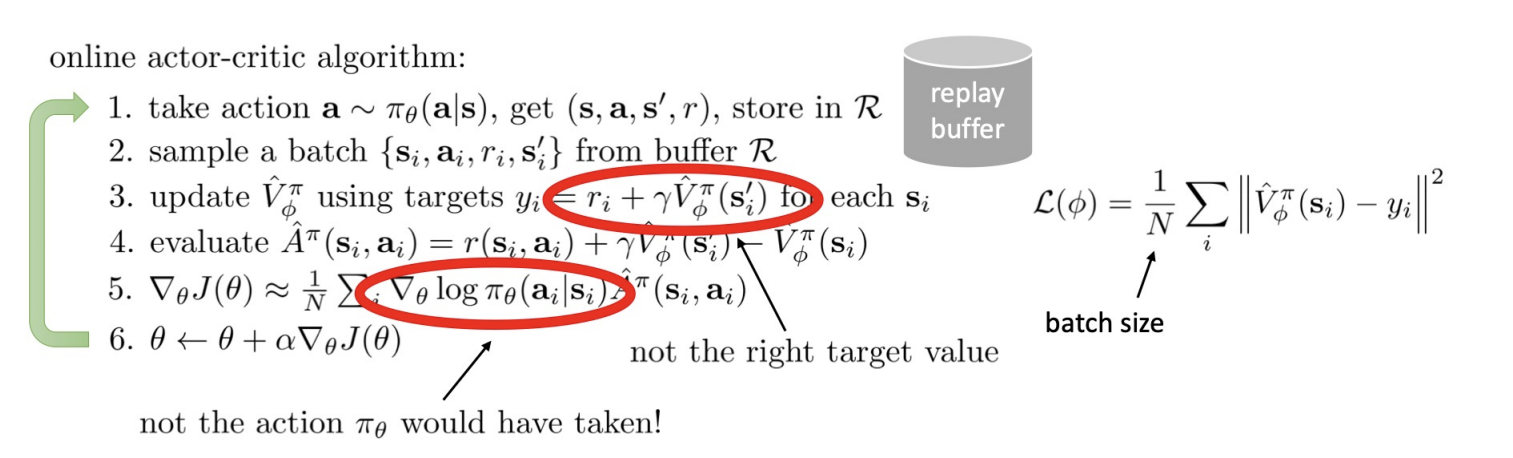

**场景设定：**
*   **Agent（智能体）：** 你是一个正在练武功的人。
*   **Policy $\pi_\theta$（当前策略）：** 你**现在**的脑子和武功水平。
*   **Replay Buffer（回放池）：** 你的一本**日记**，里面记录了你**三个月前**（旧策略 $\pi_{old}$）练功的过程。
    *   日记格式是：`{状态s: 遇到老虎, 动作a: 滑铲, 奖励r: 被咬了(-10), 下一状态s': 医院}`。

**PPT中第一个红圈的问题（第3行）：价值估计错位**

> 公式：$y_i = r_i + \gamma \hat{V}_{\phi}^\pi(s_i')$

*   **翻译成人话：** 你想评估“遇到老虎”这个状态对**现在的你**来说价值是多少。
*   **公式的做法：** 它把“三个月前滑铲被咬的痛苦（$r_i$）”加上“现在的你进医院后的未来预期（$V(s')$）”加在了一起。
*   **为什么错了？**
    *   $r_i$ 是**旧动作**（滑铲）带来的后果。
    *   $\hat{V}_{\phi}^\pi$ 评估的是**现在的你**（现在的你可能已经学会“爬树”了，根本不会滑铲）。
    *   **矛盾点：** 你现在的策略如果是“爬树”，你就不会得到“被咬”这个惩罚。强行把旧动作的惩罚（$r_i$）算在现在的策略头上，会导致对当前价值的评估完全错误。这就像评价你现在的厨艺，却把三个月前烧焦的菜的味道算进去了。

**PPT中第二个红圈的问题（第5行）：策略更新错位**

> 公式：$\nabla_\theta \log \pi_\theta(a_i|s_i)$

*   **翻译成人话：** 我们要计算梯度来更新你的脑子，让你下次做得更好。这里用到的是日记里的动作 $a_i$（滑铲）。
*   **公式的做法：** 它在问：“对于现在的脑子 $\pi_\theta$ 来说，我是不是应该增加‘滑铲’的概率？”
*   **为什么错了？**
    *   强化学习的梯度更新（Policy Gradient）有一个基本假设：**数据必须是你当前的脑子产生的**。
    *   你现在的脑子可能觉得“遇到老虎应该爬树”。但数据里只有“滑铲”。
    *   如果你直接拿这个数据去算，你其实是在优化“如何让三个月前的那个傻瓜（旧策略）做得更好”，而不是优化“现在的你”。你在对着错误的试卷改错题。

---

#### 修正 Critic

既然直接评估“状态 $s$”的价值（$V$函数）会因为旧动作 $a$ 而出问题，那我们换个思路。

*   **旧思路 ($V$)：** 站在老虎面前（$s$），我现在的脑子能得多少分？
    *   *难点：* 以前的日记里做了个滑铲，现在的我想爬树，对不上号。
*   **新思路 ($Q$)：** 站在老虎面前（$s$），如果**强制执行**日记里的动作（滑铲 $a$），然后**之后**再按现在的脑子打，能得多少分？
    *   这就是 **$Q(s, a)$** 函数的定义。

**修正逻辑：**
*   我们不再直接学 $V(s)$，改为学 $Q(s, a)$。
*   **为什么这样就对了？**
    *   日记里写着：`{遇到老虎, 滑铲, 被咬了, 进医院}`。
    *   对于 $Q(s, a)$ 来说，它评估的是“**如果**做动作 $a$”。
    *   日记正好提供了“做了动作 $a$（滑铲）”的真实后果（被咬 $r$ + 进医院 $s'$）。
    *   所以，$Q$ 函数的更新目标变成了：$y = r_{日记} + \gamma V_{新脑子}(s'_{日记})$。
    *   **妙在哪里？** $r$（被咬）和 $s'$（进医院）是物理事实，跟谁做决策无关。只有到了 $s'$ 之后，才轮到新脑子（新策略 $\pi$）发挥作用。这样就成功把“旧动作的影响”和“新策略的未来”接上了轨。

---

#### 修正 Actor

既然我们已经修好了评价体系（Critic/Q函数），现在我们可以利用它来修正我们的脑子（Actor）了。

日记里的动作 $a$（滑铲）是垃圾，不能用来训练现在的脑子。那怎么办？**我们只用日记里的状态 $s$（老虎）！**

**操作流程（详细不跳步）：**

1.  **取状态：** 从日记里读出一条记录，只看状态 $s_i$：“当时面前有一只老虎”。
2.  **问自己：** 忽略日记里写的“滑铲”，问你**现在**的脑子 $\pi_\theta$：“如果是现在的你，看到这只老虎 $s_i$，你会做什么？”
3.  **重新采样（Resample）：** 你现在的脑子回答：“我会爬树（$a_{new}$）”。（注意：这个动作是**现在**想出来的，不是日记里的）
4.  **打分：** 问刚刚修好的 $Q$ 函数（Critic）：“喂，如果在状态 $s_i$，我做动作 $a_{new}$（爬树），能得多少分？”
    *   $Q$ 函数会预测出一个分数（即使日记里没记录爬树，神经网络也能通过泛化预测出来）。
5.  **更新：** 既然 $Q$ 函数说“爬树”分高，那就调整参数，让下次“爬树”的概率更高。

**PPT红圈解释（第5行）：**
$$ \nabla_\theta J \approx \frac{1}{N} \sum \nabla_\theta \log \pi_\theta(a_i^\pi | s_i) \cdot \hat{Q}^\pi(s_i, a_i^\pi) $$

*   注意这里的 $a_i^\pi$（上标 $\pi$ 表示来自新策略）。
*   它**不是** Buffer 里的旧动作 $a_i$。
*   它是**现在**的策略 $\pi_\theta$ 看到状态 $s_i$ 后，现场想出来的**新动作**。
*   这样一来，动作是新的，评价是针对新动作的，梯度也就是正确的了。

不管怎么修正，Si都不是正确的。

### 重要性采样 (Importance Sampling) 
引入重要性采样 (Importance Sampling) 实现 Off-Policy
为了利用旧策略 $\pi_{\theta_{old}}$ 产生的数据来更新新策略 $\pi_\theta$，引入重要性采样比率：
$$ \frac{p_\theta(\tau)}{p_{\theta_{old}}(\tau)} \approx \prod_{t=1}^T \frac{\pi_\theta(a_t|s_t)}{\pi_{\theta_{old}}(a_t|s_t)} $$
*   **问题：** 如果新旧策略分布差异过大（即 $\frac{\pi_\theta}{\pi_{\theta_{old}}}$ 偏离1太远），会导致梯度估计的方差爆炸，甚至导致策略分布崩溃（Training collapsed）。

#### TRPO (Trust Region Policy Optimization)
为了解决分布偏移问题，TRPO在优化目标中加入硬约束（Hard Constraint）：
*   **核心思想：** 限制每次策略更新的幅度，使其在“信任区域”内。
*   **数学形式：**
    $$ \max_\theta \mathcal{L}(\theta_k, \theta) \quad \text{s.t.} \quad \bar{D}_{KL}(\theta || \theta_k) \le \delta $$
*   **求解难点：** 涉及泰勒展开、拉格朗日对偶、共轭梯度法（Conjugate Gradient）求解黑塞矩阵逆 $H^{-1}g$ 以及回溯线搜索（Backtracking Line Search）。计算极其昂贵且实现复杂。

#### PPO（Proximal Policy Optimization，近端策略优化）

PPO是目前**具身智能和机器人控制领域的绝对王者**。

##### KL 散度（KL Divergence）

它是 TRPO算法 和 PPO 变体中的核心概念。

1. 通俗理解
   
想象你在考驾照：
*   **分布 P（旧策略）：** 你昨天练车的习惯（比如看到红灯刹车力度是 50%）。
*   **分布 Q（新策略）：** 教练教你今天的新习惯（看到红灯刹车力度是 60%）。

**KL 散度就是一把“尺子”，用来测量“你今天的新习惯”和“昨天的旧习惯”差得有多远。**
*   如果 $KL(P || Q)$ 很小：说明你今天的改变不大，还在稳步学习。
*   如果 $KL(P || Q)$ 很大：说明你今天的开车方式跟昨天完全不一样（比如昨天用脚刹，今天突然改用手刹了），这在强化学习里非常危险！

2. 为什么机器人怕“大变”
   
在机器人控制里，如果我们更新策略时不加限制，网络可能会因为一次偶然的奖励，突然把参数改得面目全非。
*   **后果：** 机器人上一秒还在走路，下一秒参数剧变，直接躺地上抽搐了。一旦策略崩溃（Collapse），机器人就再也站不起来了，因为数据全是躺在地上采集的垃圾数据。

##### PPO 的核心原理

PPO 之所以牛，是因为它既保证了“小步快跑”（不让策略剧烈变化），又把数学做得特别简单（比它的前辈 TRPO 简单得多）。

它的核心法宝叫做：**裁剪（Clipping）**。

我们通过一个场景来理解 PPO 究竟在做什么。

**场景设定**
*   **机器人狗**正在学走路。
*   **动作 $a$：** 迈出左腿。
*   **优势函数 $A$（Advantage）：** 这一步迈得好不好？
    *   如果 $A > 0$：迈得好！比平均水平强，应该奖励。
    *   如果 $A < 0$：迈得烂！差点摔倒，应该惩罚。
*   **概率比率 $r$（Ratio）：** $\frac{\text{新策略做该动作的概率}}{\text{旧策略做该动作的概率}}$。
    *   $r > 1$：新策略更倾向于做这个动作。
    *   $r < 1$：新策略想减少做这个动作。

PPO 的逻辑：好的要克制，坏的也要克制

PPO 的目标函数设计了这样一种机制：

**情况一：这一步做得好（$A > 0$）**
*   **本能反应：** 既然这步迈得好，那就疯狂增加做这个动作的概率！让 $r$ 变得无限大！
*   **PPO 说：** 慢着！增加概率是可以的，但是**不能超过一个上限**（比如 $1 + \epsilon$，通常 $\epsilon=0.2$）。
    *   即使你觉得这个动作再好，新策略做这个动作的概率，最多只能是旧策略的 1.2 倍。
    *   **为什么？** 防止自信过头。也许这次迈得好只是运气好，改动太大万一后面掉坑里怎么办？

**情况二：这一步做得差（$A < 0$）**
*   **本能反应：** 既然这步差点摔倒，那就疯狂减少概率，以后再也不许迈左腿了！
*   **PPO 说：** 慢着！减少概率是可以的，但是**不能低于一个下限**（比如 $1 - \epsilon$，即 0.8 倍）。
    *   **为什么？** 防止矫枉过正。也许只是这块地比较滑，动作本身没大错，彻底抹杀这个动作会导致机器人“不敢动”。

**PPO 就是一个带着“镣铐”跳舞的老师。它允许机器人根据表现更新策略，但强制要求新策略和旧策略的差异必须限制在一个小范围（Clip）内，不管是变好还是变坏，都不能太激进。**

##### PPO 怎么用

1.  **采样（Rollout）：**
    *   让机器人（Agent）用**当前**的脑子（策略 $\pi_{old}$）在环境里跑几步（比如跑2048步）。
    *   记录下一堆数据：`[状态, 动作, 奖励, 下一状态]`。
    *   *注意：这里就是上一节课讲的，用 On-Policy 方式收集数据。*

2.  **计算优势（Advantage Calculation）：**
    *   算出每一步动作到底是“好”还是“坏”（计算 $A_t$）。
    *   通常用到 **GAE (Generalized Advantage Estimation)** 这个技巧，用来平衡偏差和方差。

3.  **优化更新（Optimization）：**
    *   把收集到的数据打乱，分成几个小批次（Mini-batch）。
    *   用 SGD 或 Adam 优化器去更新网络参数。
    *   **关键点：** 更新的时候，计算 Loss 就用到上面说的 **Clip** 机制，限制更新幅度。

4.  **循环：**
    *   更新完网络后，旧脑子变成了新脑子。
    *   删掉旧数据，回到第1步，用新脑子再去收集数据。

##### “调参”到底在调什么

RL 比较“玄学”，对参数非常敏感。所谓的**超参数（Hyperparameters）**，就是你需要手动设置、机器不会自己学的数字。主要有这几个：

1.  **Learning Rate（学习率）：**
    *   *含义：* 每次更新参数迈多大步。
    *   *太大了：* 震荡，学不会，甚至 reward 变成负无穷。
    *   *太小了：* 也就是机器人狗可能练了一万年还在原地踏步。

2.  **Clip Range ($\epsilon$)：**
    *   *含义：* 就是上面说的“镣铐”有多紧。通常是 0.1 或 0.2。
    *   *调参：* 如果你发现机器人学得很快但不稳定，可能要调小；如果学不动，可能要调大。

3.  **Entropy Coefficient（熵系数）：**
    *   *含义：* 鼓励机器人“多尝试新动作”的程度。
    *   *调参：* 如果机器人这辈子只敢站着不敢走（陷入局部最优），说明它太怂了，要**调大**熵系数，逼它去探索未知；如果机器人像个疯子一样乱动收敛不了，要**调小**。

4.  **Mini-batch Size 和 Number of Epochs：**
    *   *含义：* 同样的一批数据，我要反复学几次？一次吃多少？
    *   *影响：* 影响训练速度和稳定性。


**代码库：** 现在的作业通常是基于 `Legged Gym` 或者 `Isaac Gym`，里面 PPO 的代码都已经写好了。你主要需要改的是 **Reward Function（奖励函数）** 和 **Config（配置文件）**。
**关注奖励设计：** 在具身智能里，**设计一个好的奖励函数（Reward Engineering）比改 PPO 算法本身更重要。** 比如你想让狗走直线，你得奖励它速度，还得惩罚它歪头，惩罚它脚滑。